In [16]:
import pandas as pd
import numpy as np
import math

In [17]:
df = pd.read_csv("../processed_data/telco_clean.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
df.drop(columns=["customerID"], inplace=True)

In [19]:
df.duplicated().sum()

np.int64(22)

In [20]:
df.drop_duplicates(inplace=True)

In [21]:
# Step 2: Encode target
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})
print(df['Churn'].value_counts())
# 0    5174   (No Churn)
# 1    1869   (Churn)

# Step 3: Separate features
X = df.drop(columns=['Churn'])
y = df['Churn']
num_cols = X.select_dtypes(
    include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(
    include=['object']).columns.tolist()
print(f"Numerical: {len(num_cols)} features")
# Numerical: 3 features  (tenure, Monthly, Total)
print(f"Categorical: {len(cat_cols)} features")
# Categorical: 16 features

# Step 4: Build Preprocessor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler, OneHotEncoder)
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer([
  ('num', StandardScaler(), num_cols),
  ('cat', OneHotEncoder(
      handle_unknown='ignore',
      sparse_output=False), cat_cols)
])


Churn
0    5164
1    1857
Name: count, dtype: int64
Numerical: 4 features
Categorical: 15 features


In [22]:
# Step 5: Stratified split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    stratify=y,   # ← CRITICAL for imbalanced data
    random_state=42)
print(f"Train: {X_train.shape}")  # (5634, 19)
print(f"Test:  {X_test.shape}")   # (1409, 19)
print(f"Train churn %: {y_train.mean()*100:.1f}%") # 26.5%
print(f"Test churn  %: {y_test.mean()*100:.1f}%")  # 26.5%

# Step 6: Feature Engineering
df['tenure_group'] = pd.cut(df['tenure'],
    bins=[0,12,24,48,72],
    labels=['New','Young','Mature','Loyal'])
df['monthly_per_tenure'] = (
    df['MonthlyCharges'] / (df['tenure']+1))
service_cols = ['PhoneService','InternetService',
  'OnlineSecurity','OnlineBackup','TechSupport']
df['num_services'] = (df[service_cols]=='Yes').sum(axis=1)


Train: (5616, 19)
Test:  (1405, 19)
Train churn %: 26.4%
Test churn  %: 26.5%


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier)
from xgboost import XGBClassifier

# Scale for imbalance: 5174/1869 ≈ 2.77
scale = (y_train==0).sum() / (y_train==1).sum()

models = {
 'Logistic Regression': LogisticRegression(
     class_weight='balanced', max_iter=1000),
 'Decision Tree': DecisionTreeClassifier(
     max_depth=6, class_weight='balanced'),
 'Random Forest': RandomForestClassifier(
     n_estimators=200, class_weight='balanced'),
 'Gradient Boosting': GradientBoostingClassifier(
     n_estimators=200, learning_rate=0.05),
 'XGBoost': XGBClassifier(
     n_estimators=300, learning_rate=0.05,
     scale_pos_weight=scale, eval_metric='logloss'),
}


In [24]:
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score)
from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score)

results = []
trained = {}
cv = StratifiedKFold(n_splits=5, shuffle=True,
                     random_state=42)

for name, clf in models.items():
    pipe = Pipeline([('prep', preprocessor),
                     ('clf', clf)])
    cv_auc = cross_val_score(
        pipe, X_train, y_train,
        cv=cv, scoring='roc_auc')
    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_test)[:,1]
    y_pred = pipe.predict(X_test)
    results.append({'Model':name,
      'CV_AUC':cv_auc.mean().round(3),
      'Test_AUC':round(roc_auc_score(y_test,y_prob),3),
      'Recall':round(recall_score(y_test,y_pred),3),
      'F1':round(f1_score(y_test,y_pred),3)
      })
    trained[name] = pipe
pd.DataFrame(results).sort_values('Test_AUC',ascending=False)


,Model,CV_AUC,Test_AUC,Recall,F1
0,Logistic Regression,0.846,0.840,0.780,0.615
3,Gradient Boosting,0.849,0.839,0.519,0.577
4,XGBoost,0.834,0.833,0.726,0.619
1,Decision Tree,0.819,0.824,0.772,0.618
2,Random Forest,0.825,0.815,0.441,0.510


In [25]:
import sklearn
print(sklearn.__version__)

1.6.1


Best AUC: 0.849


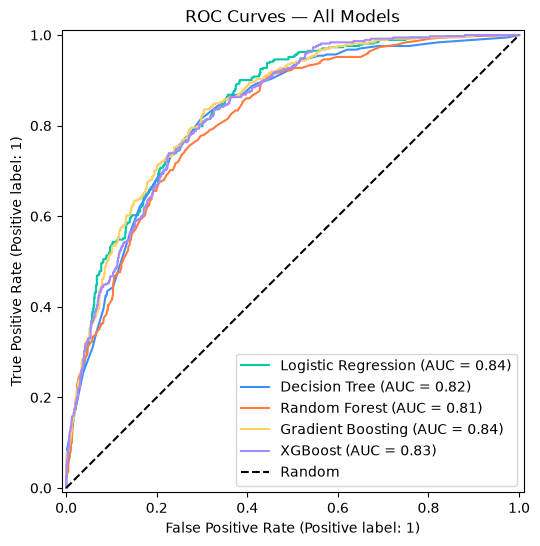

In [26]:
# Step 1: ROC Curve for all models
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,6))
colors = ['#00C9A7','#3D8EFF','#FF7A3D',
          '#FFD166','#A78BFA']
for (name, pipe), color in zip(trained.items(),colors):
    y_prob = pipe.predict_proba(X_test)[:,1]
    RocCurveDisplay.from_predictions(
        y_test, 
        y_prob, 
        ax=ax,
        name=name, 
        color=color
        )
ax.plot([0,1],[0,1],'k--', label='Random')
ax.set_title('ROC Curves — All Models')
ax.legend(loc='lower right')
plt.savefig('../reports/roc_curves.png', dpi=150)

# Step 4: RandomizedSearchCV tuning
xgb_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
 'clf__n_estimators': [100,200,300,500],
 'clf__max_depth': [3,4,5,6,7],
 'clf__learning_rate': [0.01,0.05,0.1],
 'clf__subsample': [0.7,0.8,0.9,1.0],
}
search = RandomizedSearchCV(
    xgb_pipe, param_grid,
    n_iter=20, cv=5, scoring='roc_auc',
    n_jobs=-1, random_state=42)
search.fit(X_train, y_train)
print("Best AUC:", search.best_score_.round(3))


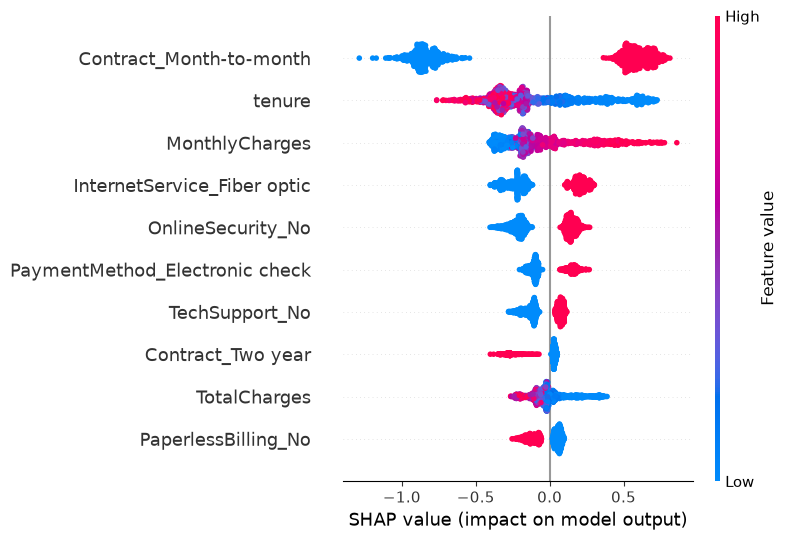

✅ Model saved!
[0.696 0.446 0.494]


In [27]:
# Step 5: SHAP Feature Importance
import shap

# Get preprocessed feature names
ohe_names = search.best_estimator_\
  .named_steps['prep']\
  .named_transformers_['cat']\
  .get_feature_names_out(cat_cols).tolist()
feature_names = num_cols + ohe_names

# Transform test data for SHAP
X_test_tr = search.best_estimator_\
  .named_steps['prep'].transform(X_test)

explainer = shap.TreeExplainer(
    search.best_estimator_.named_steps['clf'])
shap_values = explainer.shap_values(X_test_tr)

# Global importance plot
shap.summary_plot(shap_values, X_test_tr,
    feature_names=feature_names, max_display=10)
# Top features: tenure, MonthlyCharges, Contract...

# Step 7: Save model
import joblib
joblib.dump(search.best_estimator_,
    '../models/churn_model_v1.pkl')
print("✅ Model saved!")
# Verify:
m = joblib.load('../models/churn_model_v1.pkl')
print(m.predict_proba(X_test[:3])[:,1].round(3))
